# AMLSim Small – Dataset Analysis

This notebook analyses the IBM AMLSim HI-Small dataset, covering:
1. **Pattern graphs** – one representative subgraph per pattern type + configurable neighbourhood
2. **Feature distributions** – all node and edge features
3. **Fraud / licit counts** – edges and nodes

In [19]:
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
PALETTE = sns.color_palette('tab10')
FRAUD_COLOR   = '#e74c3c'
LICIT_COLOR   = '#3498db'
NEUTRAL_COLOR = '#2ecc71'

DATA_DIR = Path('data/ibm_amlsim')
print('Data directory:', DATA_DIR.resolve())

Data directory: C:\Users\marti\OneDrive\Desktop\Tesi v2\Code\data\ibm_amlsim


## 1. Load raw data

In [20]:
# ── Transactions ──────────────────────────────────────────────────────────────
trans = pd.read_csv(
    DATA_DIR / 'HI-Small_Trans.csv',
    dtype={
        'From Bank': str, 'Account': str,
        'To Bank': str,   'Account.1': str,
    }
)

# The two 'Account' columns get renamed by pandas to Account / Account.1
trans.columns = [
    'Timestamp', 'From Bank', 'From Account',
    'To Bank',   'To Account',
    'Amount Received', 'Receiving Currency',
    'Amount Paid',     'Payment Currency',
    'Payment Format',  'Is Laundering'
]
trans['Timestamp'] = pd.to_datetime(trans['Timestamp'])

# Unique account identifier = bank + account (avoids cross-bank collisions)
trans['src'] = trans['From Bank'].str.strip() + '_' + trans['From Account'].str.strip()
trans['dst'] = trans['To Bank'].str.strip()   + '_' + trans['To Account'].str.strip()

print(f'Transactions: {len(trans):,}  |  columns: {list(trans.columns)}')
trans.head(5)

Transactions: 5,078,345  |  columns: ['Timestamp', 'From Bank', 'From Account', 'To Bank', 'To Account', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering', 'src', 'dst']


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,src,dst
0,2022-09-01 00:20:00,010,8000EBD30,010,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0,010_8000EBD30,010_8000EBD30
1,2022-09-01 00:20:00,03208,8000F4580,001,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0,03208_8000F4580,001_8000F5340
2,2022-09-01 00:00:00,03209,8000F4670,03209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0,03209_8000F4670,03209_8000F4670
3,2022-09-01 00:02:00,012,8000F5030,012,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0,012_8000F5030,012_8000F5030
4,2022-09-01 00:06:00,010,8000F5200,010,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0,010_8000F5200,010_8000F5200


In [21]:
# ── Accounts ──────────────────────────────────────────────────────────────────
accounts = pd.read_csv(DATA_DIR / 'HI-Small_accounts.csv', dtype=str)
accounts.columns = ['Bank Name', 'Bank ID', 'Account Number', 'Entity ID', 'Entity Name']
accounts['node_id'] = accounts['Bank ID'].str.strip() + '_' + accounts['Account Number'].str.strip()

print(f'Accounts: {len(accounts):,}  |  columns: {list(accounts.columns)}')
accounts.head(5)

Accounts: 518,581  |  columns: ['Bank Name', 'Bank ID', 'Account Number', 'Entity ID', 'Entity Name', 'node_id']


,Bank Name,Bank ID,Account Number,Entity ID,Entity Name,node_id
0,Portugal Bank #4507,331579,80B779D80,80062E240,Sole Proprietorship #50438,331579_80B779D80
1,Canada Bank #27,210,809D86900,800C998A0,Corporation #33520,210_809D86900
2,UK Bank #33,21884,80812BE00,800C47F50,Partnership #35397,21884_80812BE00
3,Germany Bank #4815,32742,81047F300,80096F0B0,Corporation #48813,32742_81047F300
4,National Bank of Harrisburg,127390,80BD8CF00,800FB8760,Corporation #889,127390_80BD8CF00


## 2. Parse the Patterns file

Each block in `HI-Small_Patterns.txt` has the form:
```
BEGIN LAUNDERING ATTEMPT - <TYPE> ...
<transaction rows (same format as Trans.csv)>
END LAUNDERING ATTEMPT - <TYPE>
```
We normalise the type to a canonical name (e.g. `FAN-OUT`, `CYCLE`, …).

In [22]:
class PatternParser:
    """Parses the AMLSim patterns file into a dict of {pattern_type -> list_of_DataFrames}."""

    # Canonical names for the known pattern types
    KNOWN_TYPES = {
        'FAN-OUT':        'Fan-Out',
        'FAN-IN':         'Fan-In',
        'CYCLE':          'Cycle',
        'SCATTER-GATHER': 'Scatter-Gather',
        'GATHER-SCATTER': 'Gather-Scatter',
        'BIPARTITE':      'Bipartite',
        'RANDOM':         'Random',
        'STACK':          'Stack',
    }

    TRANS_COLS = [
        'Timestamp', 'From Bank', 'From Account',
        'To Bank',   'To Account',
        'Amount Received', 'Receiving Currency',
        'Amount Paid',     'Payment Currency',
        'Payment Format',  'Is Laundering'
    ]

    def __init__(self, path: Path):
        self.path = path

    @staticmethod
    def _canonical(raw_type: str) -> str:
        """Map raw pattern header tokens to a canonical name."""
        raw_upper = raw_type.strip().upper()
        for key, name in PatternParser.KNOWN_TYPES.items():
            if raw_upper.startswith(key):
                return name
        return raw_type.strip()

    @staticmethod
    def _parse_row(line: str) -> list | None:
        """Try to parse a comma-separated transaction line. Returns None on failure."""
        parts = line.strip().split(',')
        if len(parts) == 11:
            return parts
        return None

    def parse(self) -> dict[str, list[pd.DataFrame]]:
        """Returns {canonical_type: [df_per_attempt, ...]}."""
        patterns: dict[str, list[pd.DataFrame]] = defaultdict(list)

        current_type: str | None = None
        current_rows: list = []

        begin_re = re.compile(r'^BEGIN LAUNDERING ATTEMPT\s*-\s*(.+)$')
        end_re   = re.compile(r'^END LAUNDERING ATTEMPT')

        with open(self.path, 'r', encoding='utf-8') as fh:
            for line in fh:
                line = line.rstrip('\n')

                m_begin = begin_re.match(line)
                if m_begin:
                    current_type = self._canonical(m_begin.group(1))
                    current_rows = []
                    continue

                if end_re.match(line):
                    if current_type and current_rows:
                        df = pd.DataFrame(current_rows, columns=self.TRANS_COLS)
                        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
                        df[['Amount Received', 'Amount Paid', 'Is Laundering']] = \
                            df[['Amount Received', 'Amount Paid', 'Is Laundering']].apply(pd.to_numeric)
                        df['src'] = df['From Bank'].str.strip() + '_' + df['From Account'].str.strip()
                        df['dst'] = df['To Bank'].str.strip()   + '_' + df['To Account'].str.strip()
                        patterns[current_type].append(df)
                    current_type = None
                    current_rows = []
                    continue

                if current_type is not None:
                    row = self._parse_row(line)
                    if row:
                        current_rows.append(row)

        return dict(patterns)


parser   = PatternParser(DATA_DIR / 'HI-Small_Patterns.txt')
patterns = parser.parse()

print('Pattern types found:')
for ptype, attempts in patterns.items():
    total_txs = sum(len(df) for df in attempts)
    print(f'  {ptype:<20} {len(attempts):5d} attempts   {total_txs:7,} transactions')

Pattern types found:
  Fan-Out                 48 attempts       342 transactions
  Cycle                   54 attempts       287 transactions
  Gather-Scatter          51 attempts       716 transactions
  Stack                   43 attempts       466 transactions
  Random                  41 attempts       191 transactions
  Bipartite               49 attempts       263 transactions
  Fan-In                  40 attempts       318 transactions
  Scatter-Gather          44 attempts       626 transactions


## 3. Pattern subgraph visualisation

For each pattern type we pick **one representative attempt** and draw its transactions as a directed graph.  
Setting `N_HOPS > 0` adds neighbours from the full transaction graph.

In [23]:
# ── PatternVisualiser ─────────────────────────────────────────────────────────


class PatternVisualiser:
    """
    Visualises AMLSim fraud patterns.

    For each pattern type one attempt is sampled at random (controlled by
    `seed`).  The plot is built in two steps:

    1. **Pattern subgraph** – all transactions in the sampled attempt are
       included unconditionally.
    2. **BFS neighbourhood** – starting from every pattern node
       simultaneously, neighbours are added level-by-level from
       `full_trans` until the number of non-fraudulent nodes reaches `L`.
    """

    def __init__(self, full_trans: pd.DataFrame):
        self.full_trans = full_trans

    # ── Private helpers ────────────────────────────────────────────────────────

    @staticmethod
    def _sample_attempt(
        patterns: dict[str, list[pd.DataFrame]],
        pattern_type: str,
        seed: int,
    ) -> pd.DataFrame:
        """Return one randomly chosen attempt DataFrame for `pattern_type`."""
        rng = np.random.default_rng(seed)
        attempts = patterns[pattern_type]
        return attempts[int(rng.integers(0, len(attempts)))]

    def _bfs_neighbourhood(
        self,
        pattern_nodes: set[str],
        L: int,
        seed: int,
    ) -> set[str]:
        """
        Multi-source BFS from `pattern_nodes` over `full_trans`.

        Only NON-fraudulent (neighbourhood) nodes count toward `L`;
        pattern nodes are never counted and never removed.
        Nodes are added level-by-level; if an entire frontier level would
        exceed `L`, it is randomly subsampled to fill the remaining budget.

        Returns the full set of visited node IDs (pattern + neighbours).
        """
        rng             = np.random.default_rng(seed)
        visited         = set(pattern_nodes)
        frontier        = set(pattern_nodes)
        neighbour_count = 0            # counts only non-pattern nodes

        while frontier and neighbour_count < L:
            mask = (
                self.full_trans['src'].isin(frontier)
                | self.full_trans['dst'].isin(frontier)
            )
            incident  = self.full_trans[mask]
            new_nodes = (
                set(incident['src']) | set(incident['dst'])
            ) - visited

            if not new_nodes:
                break

            budget = L - neighbour_count
            if len(new_nodes) > budget:
                new_nodes = set(
                    rng.choice(sorted(new_nodes), size=budget, replace=False)
                )

            visited         |= new_nodes
            frontier         = new_nodes
            neighbour_count += len(new_nodes)

        return visited

    def _build_graph(
        self,
        attempt_df: pd.DataFrame,
        L: int,
        seed: int,
    ) -> tuple[nx.MultiDiGraph, set[str]]:
        """
        Build the final graph for one pattern attempt.

        Returns
        -------
        G             : MultiDiGraph with pattern + neighbourhood edges
        pattern_nodes : set of node IDs that belong to the fraud pattern
        """
        pattern_nodes = set(attempt_df['src']) | set(attempt_df['dst'])
        visited       = self._bfs_neighbourhood(pattern_nodes, L, seed)

        # Edges where BOTH endpoints are in the visited set
        mask        = (
            self.full_trans['src'].isin(visited)
            & self.full_trans['dst'].isin(visited)
        )
        subgraph_df = self.full_trans[mask]

        G = nx.MultiDiGraph()

        # 1 – All pattern edges (unconditional, no self-loops)
        for _, row in attempt_df.iterrows():
            if row['src'] != row['dst']:
                G.add_edge(
                    row['src'], row['dst'],
                    amount=row['Amount Paid'],
                    currency=row['Payment Currency'],
                    fmt=row['Payment Format'],
                    fraud=int(row['Is Laundering']),
                )

        # 2 – Neighbourhood edges (no self-loops)
        for _, row in subgraph_df.iterrows():
            if row['src'] != row['dst']:
                G.add_edge(
                    row['src'], row['dst'],
                    amount=row['Amount Paid'],
                    currency=row['Payment Currency'],
                    fmt=row['Payment Format'],
                    fraud=int(row['Is Laundering']),
                )

        return G, pattern_nodes

    @staticmethod
    def _best_layout(G: nx.MultiDiGraph, seed: int) -> dict:
        """
        Kamada-Kawai (minimises edge crossings) with spring-layout fallback.
        """
        try:
            return nx.kamada_kawai_layout(G)
        except Exception:
            return nx.spring_layout(G, seed=seed, k=1.5)

    @staticmethod
    def _legend_elements() -> list:
        return [
            mpatches.Patch(color=FRAUD_COLOR,   label='Pattern node / fraudulent edge'),
            mpatches.Patch(color=NEUTRAL_COLOR, label='Neighbourhood node'),
            mpatches.Patch(color=LICIT_COLOR,     label='Licit edge'),
        ]

    def _draw_single(
        self,
        ax: plt.Axes,
        G: nx.MultiDiGraph,
        pattern_nodes: set[str],
        title: str,
        seed: int = 42,
    ) -> None:
        """Render graph G on ax; fraud-pattern nodes/edges are highlighted."""
        node_colors = [
            FRAUD_COLOR if n in pattern_nodes else NEUTRAL_COLOR
            for n in G.nodes()
        ]
        edge_colors = [
            FRAUD_COLOR if d.get('fraud', 0) else LICIT_COLOR
            for _, _, d in G.edges(data=True)
        ]
        pos    = self._best_layout(G, seed)
        labels = {n: n[-7:] for n in G.nodes()}

        nx.draw_networkx_nodes(
            G, pos, ax=ax,
            node_color=node_colors, node_size=350, alpha=0.9
        )
        nx.draw_networkx_labels(
            G, pos, labels=labels, ax=ax, font_size=5.5, font_color='white'
        )
        nx.draw_networkx_edges(
            G, pos, ax=ax,
            edge_color=edge_colors, arrows=True,
            arrowsize=12, width=1.2,
            connectionstyle='arc3,rad=0.1'
        )
        ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
        ax.axis('off')

    # ── Public API ─────────────────────────────────────────────────────────────

    def print_graph(
        self,
        pattern_type: str,
        patterns: dict[str, list[pd.DataFrame]],
        seed: int = 42,
        L: int = 10,
    ) -> None:
        """
        Plot a single pattern type with its BFS neighbourhood.

        Parameters
        ----------
        pattern_type : str
            Canonical pattern name, e.g. 'Fan-Out', 'Cycle'.
        patterns : dict
            Output of PatternParser.parse().
        seed : int
            Controls which attempt is sampled and the BFS tie-breaking.
        L : int
            Maximum number of NON-FRAUDULENT neighbour nodes to add
            (pattern nodes are always fully included).
        """
        attempt_df       = self._sample_attempt(patterns, pattern_type, seed)
        G, pattern_nodes = self._build_graph(attempt_df, L, seed)

        n_pattern = len(pattern_nodes)
        n_neigh   = G.number_of_nodes() - n_pattern
        title = (
            f'{n_pattern+n_neigh} nodes, '
            f'{G.number_of_edges()} edges'
        )
        fig, ax = plt.subplots(figsize=(7, 6))
        self._draw_single(ax, G, pattern_nodes, title, seed=seed)
        fig.legend(handles=self._legend_elements(), loc='lower center',
                   ncol=3, fontsize=9, bbox_to_anchor=(0.5, 0))
        plt.tight_layout()
        plt.show()

    def plot_all(
        self,
        patterns: dict[str, list[pd.DataFrame]],
        n_cols: int = 4,
        seeds: list[int] | int = 42,
        Ls: list[int] | int = 10,
    ) -> None:
        """
        Plot all pattern types in a single figure arranged in a grid.

        Parameters
        ----------
        patterns : dict
            Output of PatternParser.parse().
        n_cols : int
            Number of columns in the subplot grid.
        seeds : int or list[int]
            Random seed(s) for attempt sampling and BFS tie-breaking.
            A single int is broadcast to all patterns; a list must have
            one entry per pattern type (in iteration order).
        Ls : int or list[int]
            Maximum non-fraudulent neighbour nodes per pattern.
            A single int is broadcast; a list must match the number of
            pattern types.
        """
        ptypes = list(patterns.keys())
        n      = len(ptypes)
        n_rows = (n + n_cols - 1) // n_cols

        # Broadcast scalars to per-pattern lists
        seed_list = seeds if isinstance(seeds, list) else [seeds] * n
        L_list    = Ls    if isinstance(Ls,    list) else [Ls]    * n

        if len(seed_list) != n or len(L_list) != n:
            raise ValueError(
                f'seeds and Ls must be scalars or lists of length {n} '
                f'(one per pattern type).'
            )

        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(n_cols * 4.5, n_rows * 4.5),
            squeeze=False,
        )
        axes_flat = axes.flatten()

        for idx, ptype in enumerate(ptypes):
            seed = seed_list[idx]
            L    = L_list[idx]

            attempt_df       = self._sample_attempt(patterns, ptype, seed)
            G, pattern_nodes = self._build_graph(attempt_df, L, seed)

            n_pattern = len(pattern_nodes)
            n_neigh   = G.number_of_nodes() - n_pattern
            title = (
                f'{ptype}\n'
                f'{n_neigh+n_pattern} nodes,'
                f'{G.number_of_edges()} edges'
            )
            self._draw_single(axes_flat[idx], G, pattern_nodes, title, seed=seed)

        for ax in axes_flat[n:]:
            ax.set_visible(False)

        fig.legend(
            handles=self._legend_elements(),
            loc='lower center', ncol=3, fontsize=9,
            bbox_to_anchor=(0.5, 0), frameon=True,
        )
        fig.suptitle(
            'AMLSim HI-Small \u2013 Pattern Visualisation',
            fontsize=13, fontweight='bold',
        )
        plt.tight_layout(rect=[0, 0.05, 1, 0.97])
        plt.show()


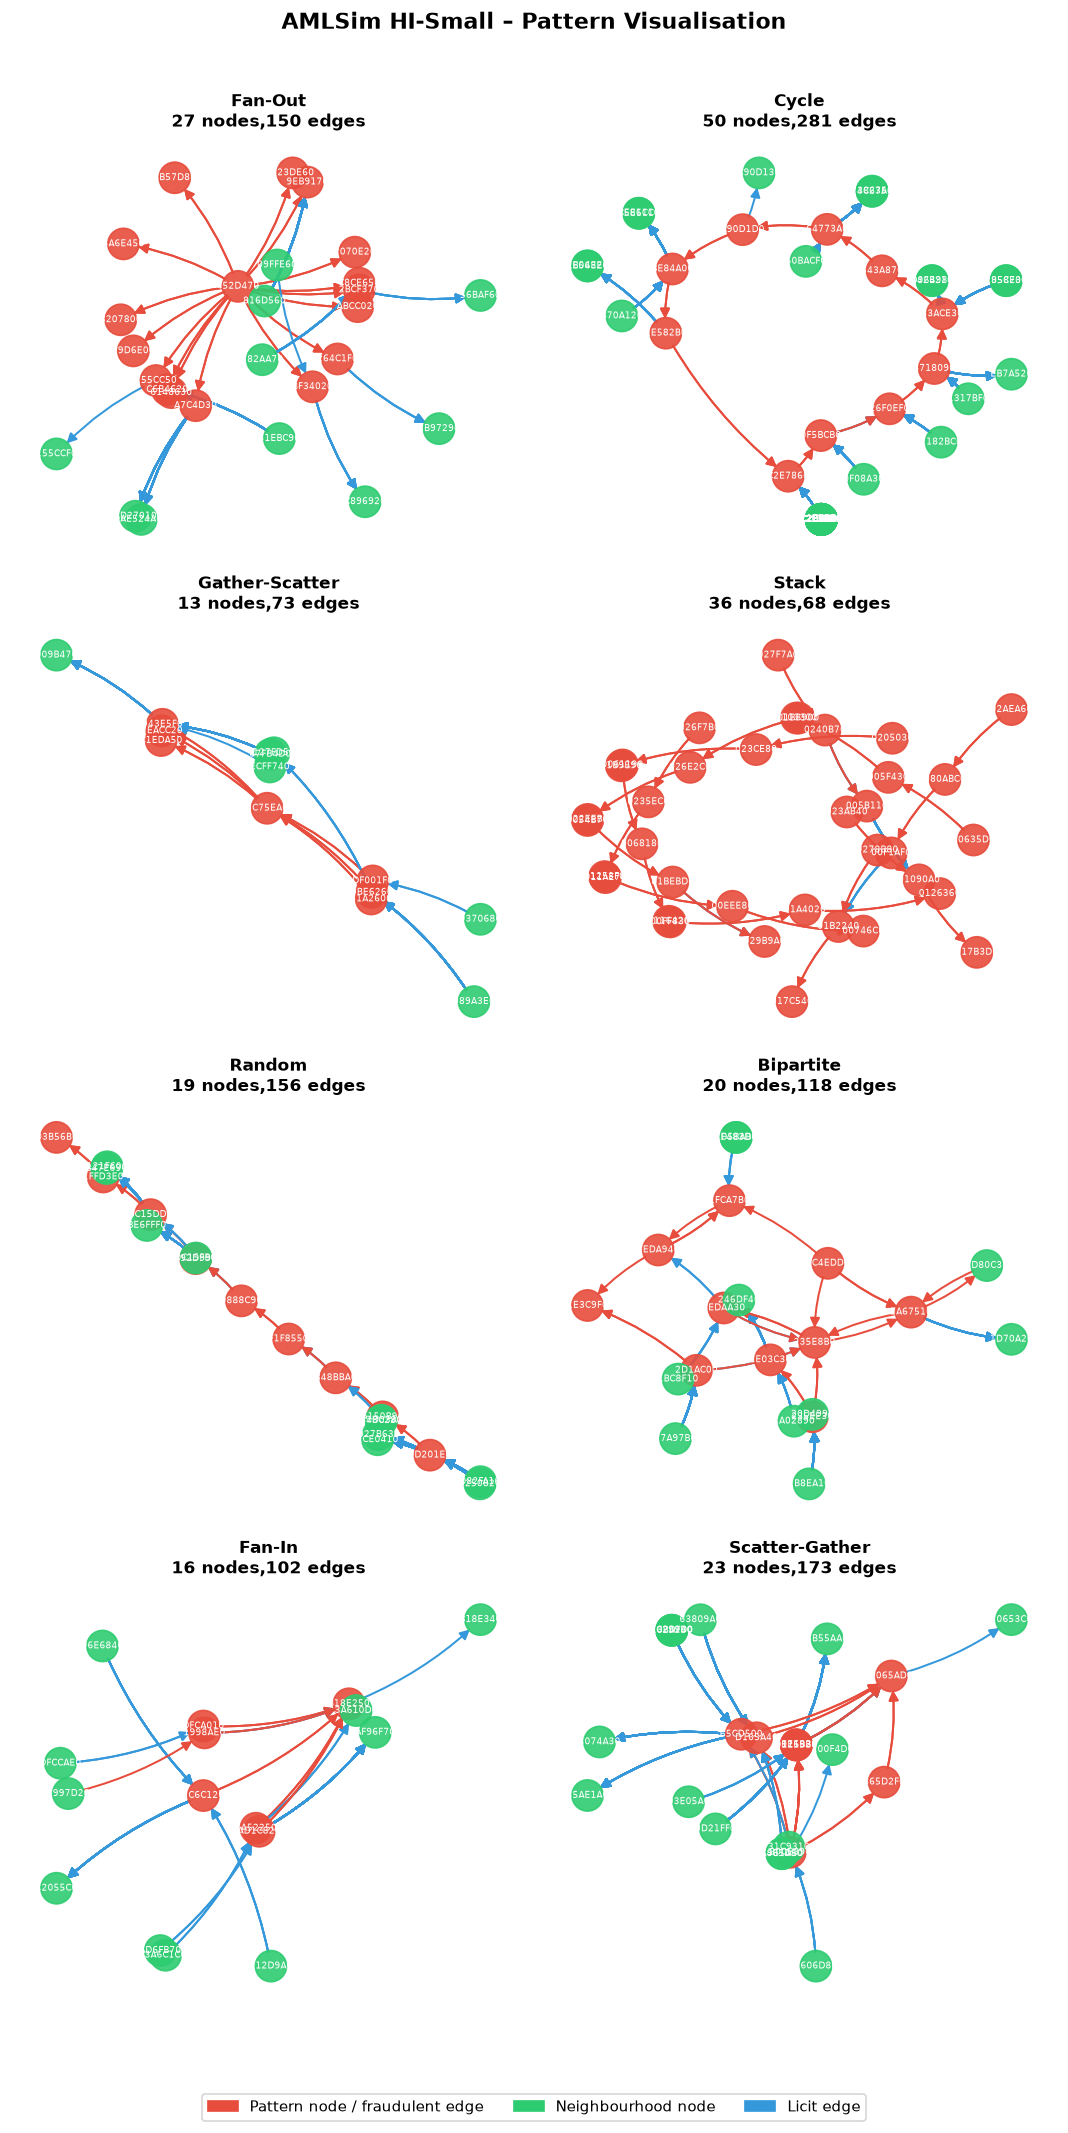

In [24]:
vis = PatternVisualiser(trans)
vis.plot_all(patterns, n_cols=2, seeds=[40,40,43,46,46,38,38,41], Ls=[10,40,6,0,10,10,10,15])

## 4. Edge feature distributions

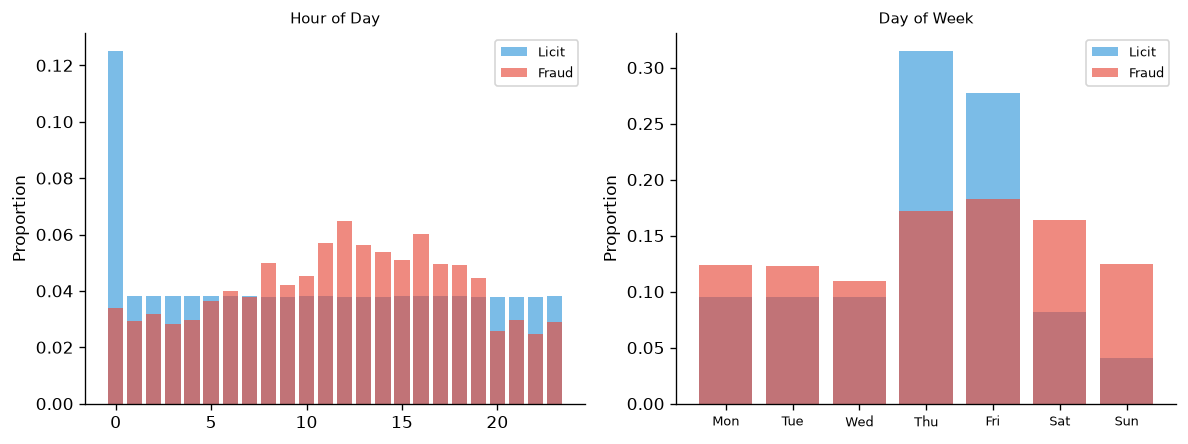

In [25]:
class EdgeFeaturePlotter:
    """
    Plots distribution of all edge features, split by licit/fraud.

    Each subplot is identified by a string key.  Pass a ``plots`` list to
    ``plot()`` to choose which subplots to render and in what order.
    Use ``None`` (default) to render everything in the default order.

    Available keys
    --------------
    Numeric histograms : 'Amount Received', 'Amount Paid'
    Categorical bars   : 'Receiving Currency', 'Payment Currency', 'Payment Format'
    Time features      : 'Hour', 'DayOfWeek'
    Counts bar chart   : 'fraud_licit_counts'
    """

    NUMERIC_COLS     = ['Amount Received', 'Amount Paid']
    CATEGORICAL_COLS = ['Receiving Currency', 'Payment Currency', 'Payment Format']
    TIME_COLS        = ['Hour', 'DayOfWeek']
    COUNT_KEY        = 'fraud_licit_counts'
    DAY_NAMES        = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

    # Default ordered list – edit to reorder or remove permanently
    ALL_PLOTS = NUMERIC_COLS + CATEGORICAL_COLS + TIME_COLS + [COUNT_KEY]

    def __init__(self, df: pd.DataFrame):
        self.df         = df
        self.fraud_mask = df['Is Laundering'] == 1

    # ── Private render helpers ────────────────────────────────────────────────

    def _plot_numeric(self, ax: plt.Axes, col: str) -> None:
        data_licit = self.df.loc[~self.fraud_mask, col]
        data_fraud = self.df.loc[self.fraud_mask,  col]
        ax.hist(np.log1p(data_licit.clip(lower=0)), bins=50,
                alpha=0.65, color=LICIT_COLOR, label='Licit', density=True)
        ax.hist(np.log1p(data_fraud.clip(lower=0)), bins=50,
                alpha=0.65, color=FRAUD_COLOR, label='Fraud', density=True)
        ax.set_title(f'{col}  (log1p scale)', fontsize=9)
        ax.set_xlabel('log(1 + amount)')
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)

    def _plot_categorical(self, ax: plt.Axes, col: str) -> None:
        vc_licit = self.df.loc[~self.fraud_mask, col].value_counts(normalize=True)
        vc_fraud = self.df.loc[self.fraud_mask,  col].value_counts(normalize=True)
        cats = sorted(set(vc_licit.index) | set(vc_fraud.index))
        x, w = np.arange(len(cats)), 0.35
        ax.bar(x - w/2, [vc_licit.get(c, 0) for c in cats], w,
               color=LICIT_COLOR, alpha=0.8, label='Licit')
        ax.bar(x + w/2, [vc_fraud.get(c, 0) for c in cats], w,
               color=FRAUD_COLOR, alpha=0.8, label='Fraud')
        ax.set_xticks(x)
        ax.set_xticklabels(cats, rotation=35, ha='right', fontsize=7)
        ax.set_title(col, fontsize=9)
        ax.set_ylabel('Proportion')
        ax.legend(fontsize=8)

    def _plot_hour(self, ax: plt.Axes) -> None:
        hour = self.df['Timestamp'].dt.hour
        for mask, color, lbl in [
            (~self.fraud_mask, LICIT_COLOR, 'Licit'),
            (self.fraud_mask,  FRAUD_COLOR, 'Fraud'),
        ]:
            counts = hour[mask].value_counts(normalize=True).sort_index()
            ax.bar(counts.index, counts.values, alpha=0.65, color=color, label=lbl)
        ax.set_title('Hour of Day', fontsize=9)
        ax.set_ylabel('Proportion')
        ax.legend(fontsize=8)

    def _plot_dayofweek(self, ax: plt.Axes) -> None:
        dow = self.df['Timestamp'].dt.dayofweek
        for mask, color, lbl in [
            (~self.fraud_mask, LICIT_COLOR, 'Licit'),
            (self.fraud_mask,  FRAUD_COLOR, 'Fraud'),
        ]:
            counts = dow[mask].value_counts(normalize=True).sort_index()
            ax.bar(counts.index, counts.values, alpha=0.65, color=color, label=lbl)
        ax.set_title('Day of Week', fontsize=9)
        ax.set_ylabel('Proportion')
        ax.set_xticks(range(7))
        ax.set_xticklabels(self.DAY_NAMES, fontsize=8)
        ax.legend(fontsize=8)

    def _plot_fraud_licit_counts(self, ax: plt.Axes) -> None:
        """Absolute transaction counts with log scale to handle class imbalance."""
        counts = self.df['Is Laundering'].map({0: 'Licit', 1: 'Fraud'}).value_counts()
        colors = [LICIT_COLOR if k == 'Licit' else FRAUD_COLOR for k in counts.index]
        bars = ax.bar(counts.index, counts.values, color=colors,
                      edgecolor='white', linewidth=1.2)
        ax.set_yscale('log')
        ax.bar_label(bars, fmt=lambda v: f'{int(v):,}', padding=4, fontsize=8)
        ax.set_title('Transaction Count (Fraud vs Licit)', fontsize=9)
        ax.set_ylabel('Count  (log scale)')

    def _dispatch(self, ax: plt.Axes, key: str) -> None:
        """Route a plot key to its render method."""
        if key in self.NUMERIC_COLS:
            self._plot_numeric(ax, key)
        elif key in self.CATEGORICAL_COLS:
            self._plot_categorical(ax, key)
        elif key == 'Hour':
            self._plot_hour(ax)
        elif key == 'DayOfWeek':
            self._plot_dayofweek(ax)
        elif key == self.COUNT_KEY:
            self._plot_fraud_licit_counts(ax)
        else:
            raise ValueError(f'Unknown plot key: {key!r}')

    # ── Public API ────────────────────────────────────────────────────────────

    def plot(
        self,
        plots: list[str] | None = None,
        n_cols: int = 3,
    ) -> None:
        """
        Render selected subplots in a grid.

        Parameters
        ----------
        plots : list[str] or None
            Ordered list of plot keys to render.  None means all plots in
            their default order (ALL_PLOTS).  Remove or reorder entries to
            customise the output.
        n_cols : int
            Number of columns in the subplot grid (default 3).
        """
        if plots is None:
            plots = list(self.ALL_PLOTS)

        nrows = (len(plots) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(nrows, n_cols,
                                 figsize=(n_cols * 5, nrows * 3.8))
        axes_flat = np.array(axes).flatten()

        for idx, key in enumerate(plots):
            self._dispatch(axes_flat[idx], key)

        for ax in axes_flat[len(plots):]:
            ax.set_visible(False)

        plt.tight_layout()
        plt.show()

EdgeFeaturePlotter(trans).plot(
    plots=[
        'Hour',
        'DayOfWeek'
    ],
    n_cols=2
)
        

'Amount Paid',
'Receiving Currency',
'Payment Currency',
'Payment Format',
'Hour',
'DayOfWeek',
'fraud_licit_counts',       

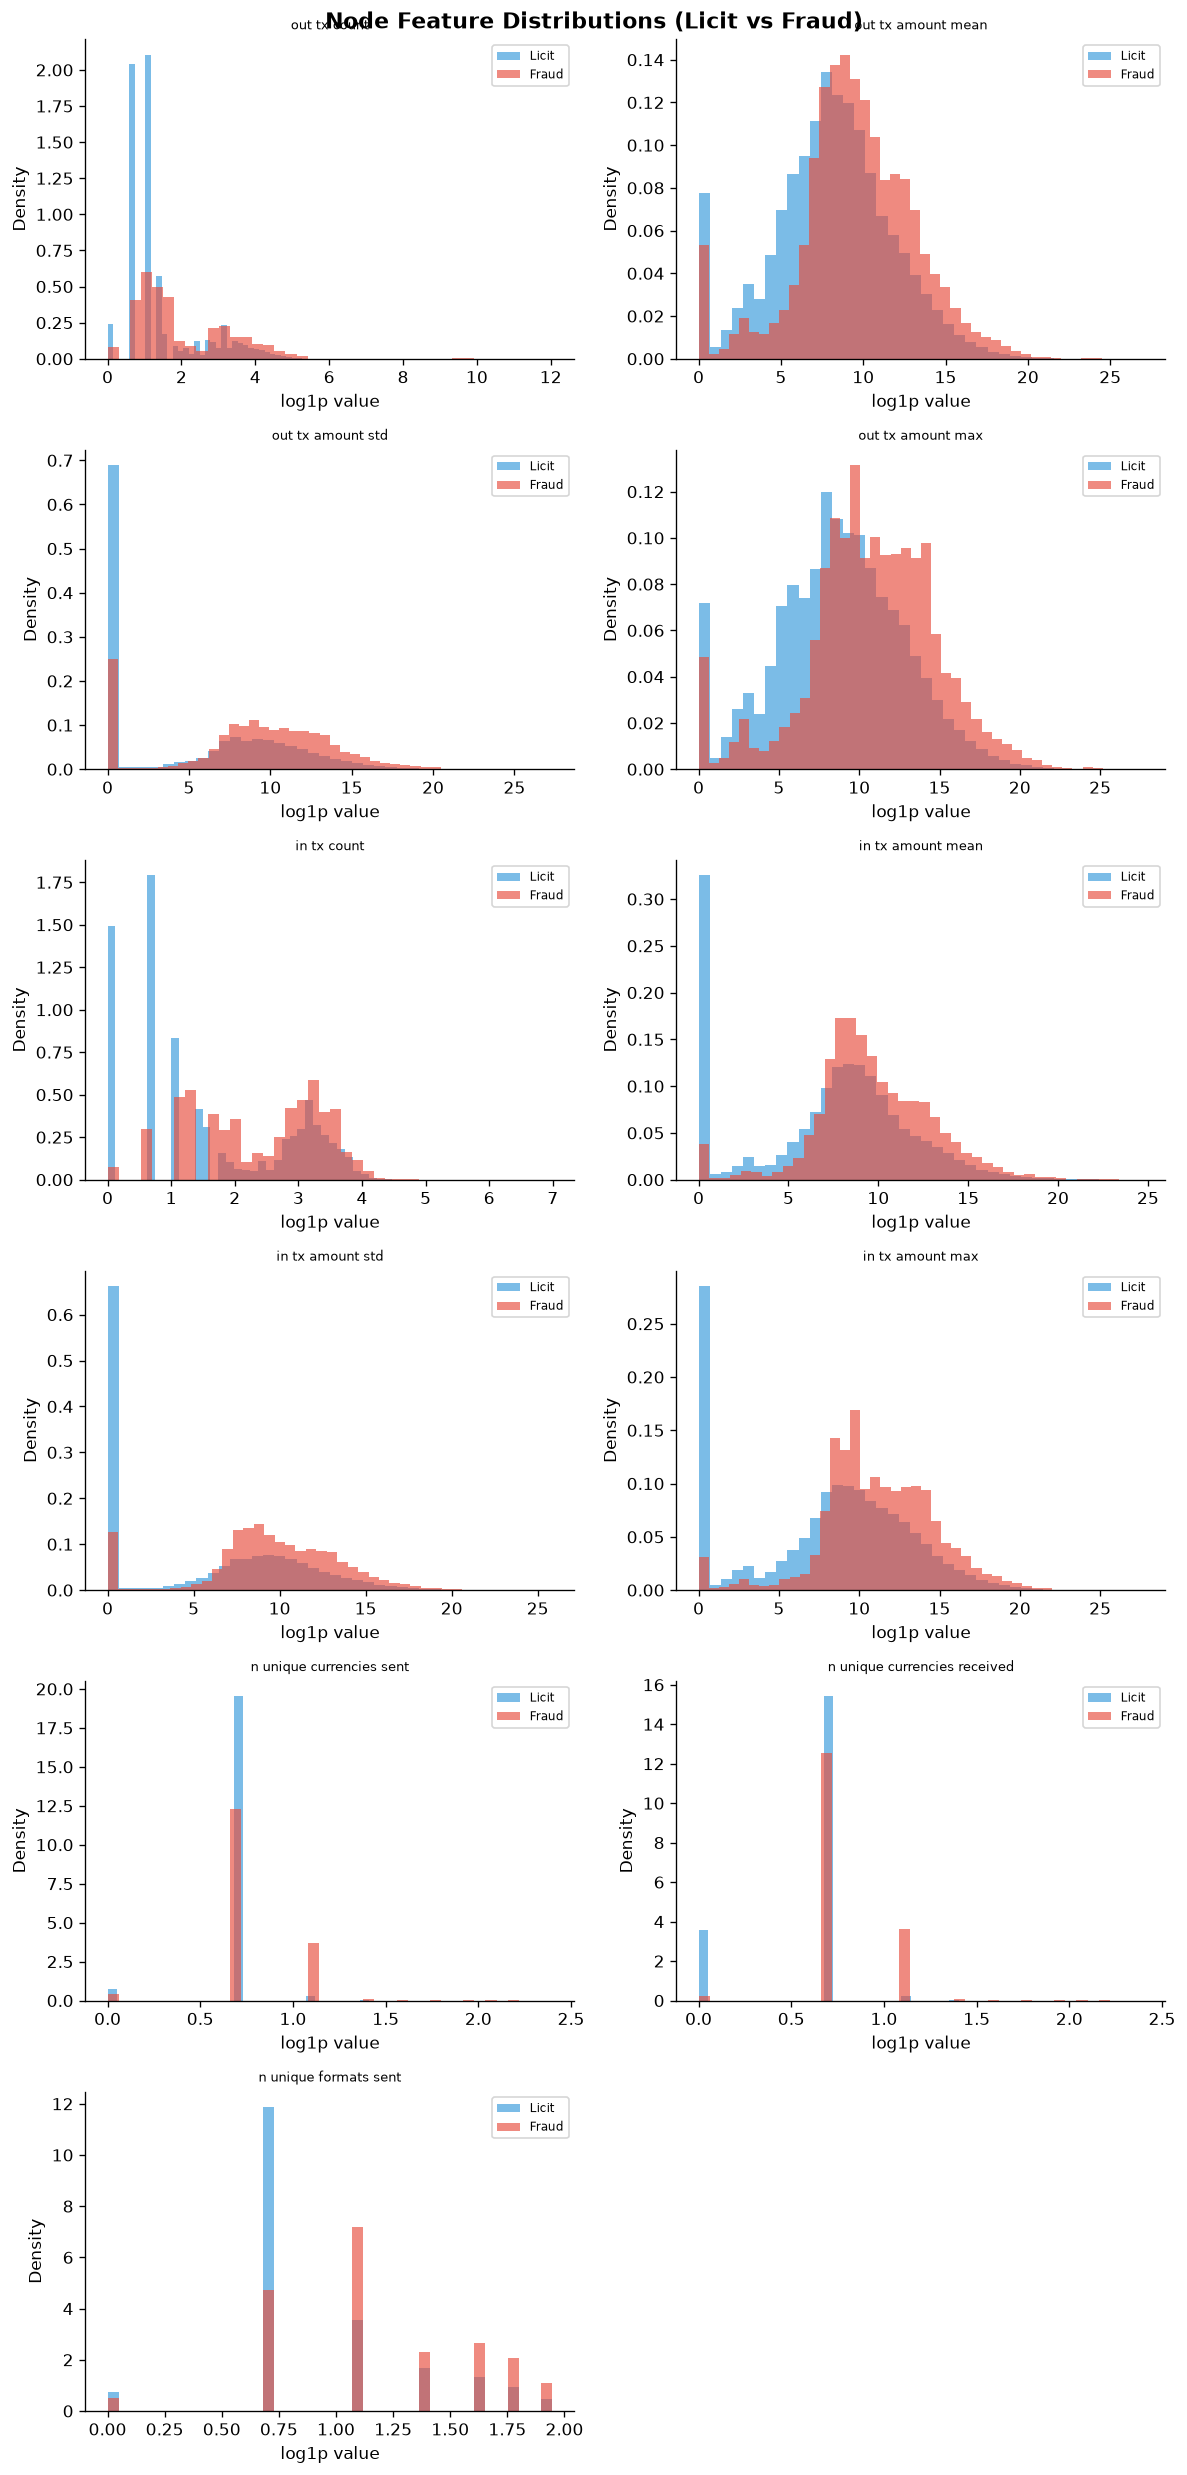

In [26]:
class NodeFeatureAnalyser:
    """
    Aggregates transaction data per node and plots the resulting feature distributions.
    A node is labelled as fraudulent if it appears in at least one fraudulent transaction.

    Each numeric feature is a plot key.  Pass a ``plots`` list to ``plot()`` to
    choose which subplots to render and in what order.  Use ``None`` (default)
    to render everything in the default order.

    Available keys (default order)
    --------------------------------
    'out_tx_count', 'out_tx_amount_mean', 'out_tx_amount_std', 'out_tx_amount_max',
    'in_tx_count',  'in_tx_amount_mean',  'in_tx_amount_std',  'in_tx_amount_max',
    'n_unique_currencies_sent', 'n_unique_currencies_received', 'n_unique_formats_sent'
    """

    # Default ordered list – edit to reorder or remove permanently
    ALL_PLOTS = [
        'out_tx_count', 'out_tx_amount_mean', 'out_tx_amount_std', 'out_tx_amount_max',
        'in_tx_count',  'in_tx_amount_mean',  'in_tx_amount_std',  'in_tx_amount_max',
        'n_unique_currencies_sent', 'n_unique_currencies_received',
        'n_unique_formats_sent',
    ]

    def __init__(self, df: pd.DataFrame):
        self.df      = df
        self.node_df = self._build_node_features()

    def _build_node_features(self) -> pd.DataFrame:
        src_agg = (
            self.df
            .groupby('src')
            .agg(
                out_tx_count=('Amount Paid',    'count'),
                out_tx_amount_mean=('Amount Paid',  'mean'),
                out_tx_amount_std=('Amount Paid',   'std'),
                out_tx_amount_max=('Amount Paid',   'max'),
                n_unique_currencies_sent=('Payment Currency', 'nunique'),
                n_unique_formats_sent=('Payment Format',     'nunique'),
                is_fraud_src=('Is Laundering',              'max'),
            )
            .rename_axis('node')
        )
        dst_agg = (
            self.df
            .groupby('dst')
            .agg(
                in_tx_count=('Amount Received',    'count'),
                in_tx_amount_mean=('Amount Received',  'mean'),
                in_tx_amount_std=('Amount Received',   'std'),
                in_tx_amount_max=('Amount Received',   'max'),
                n_unique_currencies_received=('Receiving Currency', 'nunique'),
                is_fraud_dst=('Is Laundering',                      'max'),
            )
            .rename_axis('node')
        )
        node_df = src_agg.join(dst_agg, how='outer').fillna(0)
        node_df['is_fraud'] = ((node_df['is_fraud_src'] + node_df['is_fraud_dst']) > 0).astype(int)
        node_df.drop(columns=['is_fraud_src', 'is_fraud_dst'], inplace=True)
        return node_df

    def _plot_feature(self, ax: plt.Axes, col: str) -> None:
        """Render a single numeric feature histogram split by fraud/licit."""
        fraud_mask = self.node_df['is_fraud'] == 1
        licit = self.node_df.loc[~fraud_mask, col]
        fraud = self.node_df.loc[fraud_mask,  col]
        ax.hist(np.log1p(licit.clip(lower=0)), bins=40,
                alpha=0.65, color=LICIT_COLOR, label='Licit', density=True)
        ax.hist(np.log1p(fraud.clip(lower=0)), bins=40,
                alpha=0.65, color=FRAUD_COLOR, label='Fraud', density=True)
        ax.set_title(col.replace('_', ' '), fontsize=8)
        ax.set_xlabel('log1p value')
        ax.set_ylabel('Density')
        ax.legend(fontsize=7)

    # ── Public API ────────────────────────────────────────────────────────────

    def plot(
        self,
        plots: list[str] | None = None,
        n_cols: int = 4,
    ) -> None:
        """
        Render selected node-feature histograms in a grid.

        Parameters
        ----------
        plots : list[str] or None
            Ordered list of feature names to plot.  None means all features
            in their default order (ALL_PLOTS).  Remove or reorder entries
            to customise the output.
        n_cols : int
            Number of columns in the subplot grid (default 4).
        """
        if plots is None:
            plots = list(self.ALL_PLOTS)

        nrows = (len(plots) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(nrows, n_cols,
                                 figsize=(n_cols * 5, nrows * 3.5))
        axes_flat = np.array(axes).flatten()

        for idx, col in enumerate(plots):
            self._plot_feature(axes_flat[idx], col)

        for ax in axes_flat[len(plots):]:
            ax.set_visible(False)

        fig.suptitle('Node Feature Distributions (Licit vs Fraud)',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()


node_analyser = NodeFeatureAnalyser(trans)
node_analyser.plot(
    plots=[
        'out_tx_count',
        'out_tx_amount_mean',
        'out_tx_amount_std',
        'out_tx_amount_max',
        'in_tx_count',
        'in_tx_amount_mean',
        'in_tx_amount_std',
        'in_tx_amount_max',
        'n_unique_currencies_sent',
        'n_unique_currencies_received',
        'n_unique_formats_sent',
    ],
    n_cols=2,
)



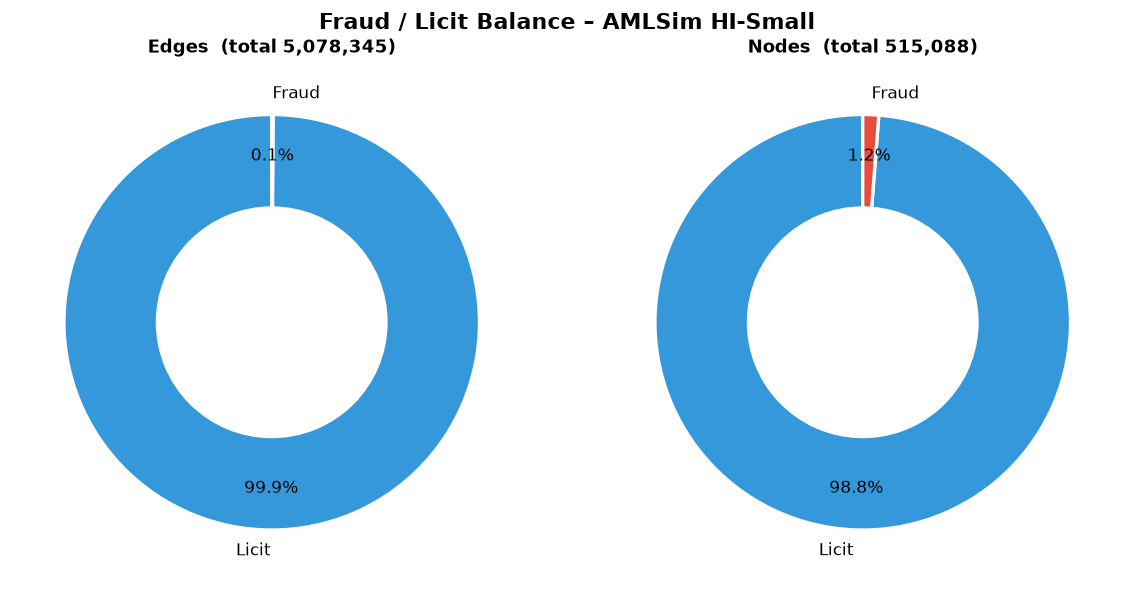


── Edge-level statistics ──
  Licit     5,073,168  (99.90%)
  Fraud         5,177  (0.10%)

── Node-level statistics ──
  Licit       508,731  (98.77%)
  Fraud         6,357  (1.23%)


In [27]:
class FraudCountPlotter:
    """Bar charts and summary statistics for edge-level and node-level fraud/licit counts."""

    def __init__(self, trans_df: pd.DataFrame, node_df: pd.DataFrame):
        self.trans_df = trans_df
        self.node_df  = node_df

    def _edge_counts(self) -> pd.Series:
        return self.trans_df['Is Laundering'].map({0: 'Licit', 1: 'Fraud'}).value_counts()

    def _node_counts(self) -> pd.Series:
        return self.node_df['is_fraud'].map({0: 'Licit', 1: 'Fraud'}).value_counts()

    def _pattern_edge_counts(self) -> pd.Series:
        """Number of fraudulent edges per pattern type (from Is Laundering = 1 rows)."""
        fraud_trans = self.trans_df[self.trans_df['Is Laundering'] == 1]
        return fraud_trans['Payment Format'].value_counts()

    @staticmethod
    def _donut(ax: plt.Axes, counts: pd.Series, title: str) -> None:
        colors = [LICIT_COLOR if k == 'Licit' else FRAUD_COLOR for k in counts.index]
        wedges, texts, autotexts = ax.pie(
            counts.values, labels=counts.index,
            colors=colors, autopct='%1.1f%%',
            startangle=90, pctdistance=0.80,
            wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)
        )
        for t in autotexts:
            t.set_fontsize(10)
        ax.set_title(title, fontsize=11, fontweight='bold')

    def plot(self) -> None:
        edge_counts = self._edge_counts()
        node_counts = self._node_counts()

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        self._donut(axes[0], edge_counts, f'Edges  (total {edge_counts.sum():,})')
        self._donut(axes[1], node_counts, f'Nodes  (total {node_counts.sum():,})')

        fig.suptitle('Fraud / Licit Balance – AMLSim HI-Small', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # Print table
        print('\n── Edge-level statistics ──')
        for label, cnt in edge_counts.items():
            print(f'  {label:<8} {cnt:>10,}  ({100*cnt/edge_counts.sum():.2f}%)')

        print('\n── Node-level statistics ──')
        for label, cnt in node_counts.items():
            print(f'  {label:<8} {cnt:>10,}  ({100*cnt/node_counts.sum():.2f}%)')


FraudCountPlotter(trans, node_analyser.node_df).plot()

## 7. Pattern-type distribution among fraudulent transactions

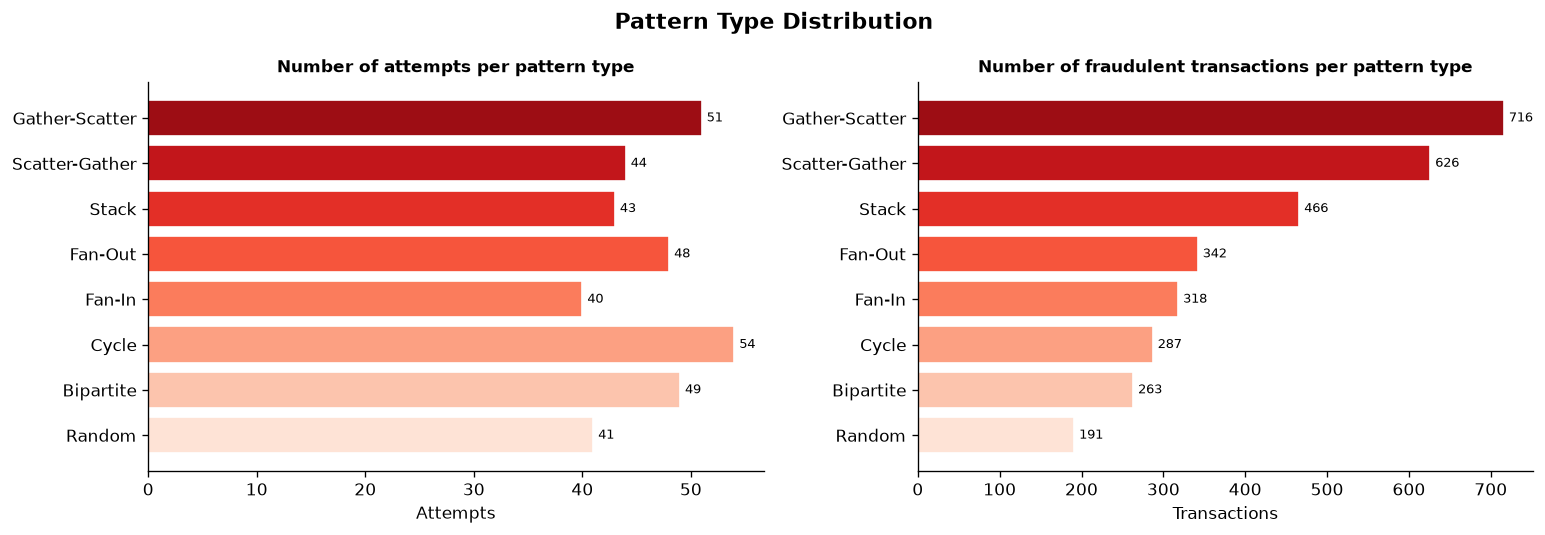

       Pattern  Attempts  Transactions
Gather-Scatter        51           716
Scatter-Gather        44           626
         Stack        43           466
       Fan-Out        48           342
        Fan-In        40           318
         Cycle        54           287
     Bipartite        49           263
        Random        41           191


In [28]:
class PatternDistributionPlotter:
    """Shows how many attempts and transactions exist per pattern type."""

    def __init__(self, patterns: dict):
        self.patterns = patterns

    def plot(self) -> None:
        records = [
            {
                'Pattern':      ptype,
                'Attempts':     len(attempts),
                'Transactions': sum(len(df) for df in attempts),
            }
            for ptype, attempts in self.patterns.items()
        ]
        df = pd.DataFrame(records).sort_values('Transactions', ascending=False)

        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

        for ax, col, title in zip(
            axes,
            ['Attempts', 'Transactions'],
            ['Number of attempts per pattern type', 'Number of fraudulent transactions per pattern type']
        ):
            bars = ax.barh(
                df['Pattern'], df[col],
                color=sns.color_palette('Reds_r', len(df)), edgecolor='white'
            )
            ax.bar_label(bars, fmt='%d', padding=3, fontsize=8)
            ax.set_xlabel(col)
            ax.set_title(title, fontsize=10, fontweight='bold')
            ax.invert_yaxis()

        fig.suptitle('Pattern Type Distribution', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()
        print(df.to_string(index=False))


PatternDistributionPlotter(patterns).plot()

## 6. Bank Transaction Distribution

For each bank we count how many times it appears as **sender** or **receiver**,
then split that count into **licit** and **illicit** transactions.  
The two panels share the same set of top-N banks (ranked by total volume)
but use **independent x-axis scales** so the illicit minority is readable.

Top-10 banks by total transaction volume:

Is Laundering                 licit  illicit   total
Bank                                                
Oasis Thrift                 452313      633  452946
National Bank of Laramie     135010      127  135137
National Bank of the East    127813      167  127980
Arbor Savings Bank           108790      115  108905
Japan Bank #0                 91144       88   91232
National Bank of Pittsburgh   83295       61   83356
Golden Bancorp                71576       76   71652
China Bank #14                64014       26   64040
Savings Bank of Fairfield     63268       54   63322
China Bank #6                 62935      121   63056


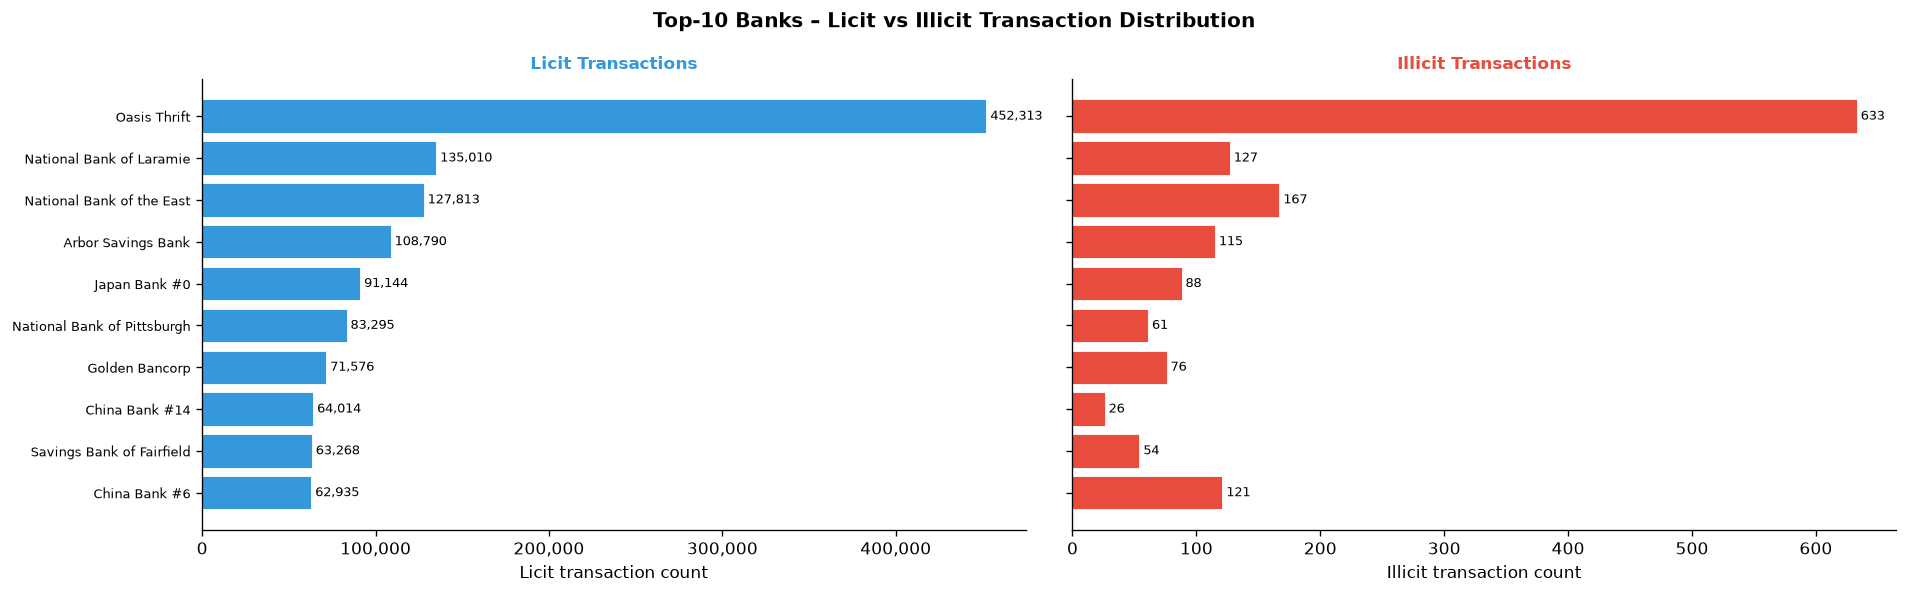

In [33]:
class BankDistributionPlotter:
    """
    Analyses and plots the licit/illicit transaction distribution across banks.

    Each bank is counted every time it appears as sender OR receiver.
    Bank IDs are resolved to human-readable names via the accounts DataFrame.
    The IDs in `trans` are zero-padded strings (e.g. '010'), while `accounts`
    stores them without padding ('10'), so we normalise both sides through int.
    """

    def __init__(self, trans: pd.DataFrame, accounts: pd.DataFrame, top_n: int = 10):
        self.trans = trans
        self.top_n = top_n
        # Build Bank-ID (normalised) -> Bank-Name lookup
        self._id_to_name: dict[str, str] = (
            accounts
            .drop_duplicates('Bank ID')
            .assign(_key=accounts['Bank ID'].str.strip().astype(int).astype(str))
            .set_index('_key')['Bank Name']
            .to_dict()
        )

    # ── Private helpers ────────────────────────────────────────────────────────

    def _normalise_id(self, bank_id: str) -> str:
        """Strip leading zeros: '010' -> '10'."""
        try:
            return str(int(bank_id))
        except (ValueError, TypeError):
            return str(bank_id)

    def _resolve_name(self, bank_id: str) -> str:
        """Return the human-readable bank name, falling back to the raw ID."""
        key = self._normalise_id(bank_id)
        return self._id_to_name.get(key, bank_id)

    def _build_bank_stats(self) -> pd.DataFrame:
        """
        Returns a DataFrame indexed by bank *name* with columns:
            licit   – licit transaction appearances
            illicit – illicit transaction appearances
            total   – licit + illicit
        """
        from_df = self.trans[['From Bank', 'Is Laundering']].rename(
            columns={'From Bank': 'Bank'}
        )
        to_df = self.trans[['To Bank', 'Is Laundering']].rename(
            columns={'To Bank': 'Bank'}
        )
        combined = pd.concat([from_df, to_df], ignore_index=True)

        # Resolve IDs -> human-readable names
        combined['Bank'] = combined['Bank'].map(self._resolve_name)

        stats = (
            combined
            .groupby(['Bank', 'Is Laundering'])
            .size()
            .unstack(fill_value=0)
            .rename(columns={0: 'licit', 1: 'illicit'})
        )
        for col in ('licit', 'illicit'):
            if col not in stats.columns:
                stats[col] = 0
        stats['total'] = stats['licit'] + stats['illicit']
        return stats

    @staticmethod
    def _annotate(ax, values, x_offset_pct=0.005):
        """Add count labels at the end of each horizontal bar."""
        max_val = values.max()
        for i, v in enumerate(values):
            ax.text(
                v + max_val * x_offset_pct, i,
                f'{int(v):,}',
                va='center', ha='left', fontsize=8
            )

    # ── Public API ─────────────────────────────────────────────────────────────

    def plot(self) -> None:
        """
        Draw two side-by-side subplots:
          Left  – licit transaction count per bank
          Right – illicit transaction count per bank
        Both panels share the same bank ordering (top-N by total volume)
        but have independent x-axis scales.
        """
        stats = self._build_bank_stats()
        top   = stats.nlargest(self.top_n, 'total').sort_values('total', ascending=True)

        # ---- Print summary table ------------------------------------------------
        print(f'Top-{self.top_n} banks by total transaction volume:\n')
        print(
            top[['licit', 'illicit', 'total']]
            .sort_values('total', ascending=False)
            .to_string()
        )

        # ---- Build chart --------------------------------------------------------
        fig, (ax_l, ax_r) = plt.subplots(
            1, 2,
            figsize=(16, max(5, self.top_n * 0.5)),
            sharey=True          # same bank labels on y-axis
        )

        banks = top.index.astype(str)
        y_pos = range(len(banks))

        # ── Left panel: licit ──────────────────────────────────────────────────
        ax_l.barh(
            y_pos, top['licit'],
            color=LICIT_COLOR, edgecolor='white', linewidth=0.5
        )
        self._annotate(ax_l, top['licit'].values)
        ax_l.set_yticks(list(y_pos))
        ax_l.set_yticklabels(banks, fontsize=8)
        ax_l.set_xlabel('Licit transaction count')
        ax_l.set_title('Licit Transactions', fontsize=10, fontweight='bold', color=LICIT_COLOR)
        ax_l.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

        # ── Right panel: illicit ───────────────────────────────────────────────
        ax_r.barh(
            y_pos, top['illicit'],
            color=FRAUD_COLOR, edgecolor='white', linewidth=0.5
        )
        self._annotate(ax_r, top['illicit'].values)
        ax_r.set_xlabel('Illicit transaction count')
        ax_r.set_title('Illicit Transactions', fontsize=10, fontweight='bold', color=FRAUD_COLOR)
        ax_r.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

        fig.suptitle(
            f'Top-{self.top_n} Banks – Licit vs Illicit Transaction Distribution',
            fontsize=12, fontweight='bold'
        )
        plt.tight_layout()
        plt.show()


BankDistributionPlotter(trans, accounts, top_n=10).plot()